### Import dependencies

In [3]:
import tarfile
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import base64

### Inspect the acrhives yelp data content


### Streaming the data from each document

In [ ]:
def stream_from_tar(tar_path, member_name, limit=5):
    """Streams JSON lines from a tar without loading the whole file into RAM."""
    with tarfile.open(tar_path, "r:*") as tar:
        f = tar.extractfile(member_name)
        if f:
            # Iterate through the file object line by line
            for i, line in enumerate(f):
                if i >= limit:
                    break
                # Parse and print/process one line at a time
                data = json.loads(line.decode("utf-8"))
                print(f"Row {i}: {data}")




In [ ]:
# Download each of the member

tar_path = Path("../data") / "yelp_dataset.tar"
output_dir = Path("../data/raw")
output_dir.mkdir(parents=True, exist_ok=True)

member_object_counts = {}

with tarfile.open(tar_path, "r:*") as tar:
    for member in tar.getmembers():
        if member.isdir():
            continue

        # Save member to disk
        target_path = output_dir / member.name
        target_path.parent.mkdir(parents=True, exist_ok=True)
        with tar.extractfile(member) as src, target_path.open("wb") as dst:
            if src is None:
                continue
            for chunk in iter(lambda: src.read(1024 * 1024), b""):
                dst.write(chunk)

        # Count number of JSON objects (lines) in this member
        count = 0
        with target_path.open("rb") as f:
            for line in f:
                # if it's JSONL, we can validate by trying to parse
                try:
                    json.loads(line.decode("utf-8"))
                    count += 1
                except Exception:
                    # non-JSONL files (e.g. PDF) will mostly fail here
                    pass

        member_object_counts[member.name] = count
        print(f"{member.name:40s} -> {count} objects")

member_object_counts



Dataset_User_Agreement.pdf               -> 1 objects
yelp_academic_dataset_business.json      -> 150346 objects
yelp_academic_dataset_checkin.json       -> 131930 objects
yelp_academic_dataset_review.json        -> 6990280 objects
yelp_academic_dataset_tip.json           -> 908915 objects
yelp_academic_dataset_user.json          -> 1987897 objects


{'Dataset_User_Agreement.pdf': 1,
 'yelp_academic_dataset_business.json': 150346,
 'yelp_academic_dataset_checkin.json': 131930,
 'yelp_academic_dataset_review.json': 6990280,
 'yelp_academic_dataset_tip.json': 908915,
 'yelp_academic_dataset_user.json': 1987897}

### Exploring business dataset

In [ ]:
# Exploring the business dataset
with  open("../data/raw/yelp_academic_dataset_business.json", "r") as f:
    first_line=json.loads(f.readline())


In [ ]:
first_line

{'business_id': 'Pns2l4eNsfO8kk83dixA6A',
 'name': 'Abby Rappoport, LAC, CMQ',
 'address': '1616 Chapala St, Ste 2',
 'city': 'Santa Barbara',
 'state': 'CA',
 'postal_code': '93101',
 'latitude': 34.4266787,
 'longitude': -119.7111968,
 'stars': 5.0,
 'review_count': 7,
 'is_open': 0,
 'attributes': {'ByAppointmentOnly': 'True'},
 'categories': 'Doctors, Traditional Chinese Medicine, Naturopathic/Holistic, Acupuncture, Health & Medical, Nutritionists',
 'hours': None}

In [ ]:
# Read the next line   
with  open("../data/raw/yelp_academic_dataset_business.json", "r") as f:
    f.readline()
    second_line=json.loads(f.readline())



In [ ]:
second_line

{'business_id': 'mpf3x-BjTdTEA3yCZrAYPw',
 'name': 'The UPS Store',
 'address': '87 Grasso Plaza Shopping Center',
 'city': 'Affton',
 'state': 'MO',
 'postal_code': '63123',
 'latitude': 38.551126,
 'longitude': -90.335695,
 'stars': 3.0,
 'review_count': 15,
 'is_open': 1,
 'attributes': {'BusinessAcceptsCreditCards': 'True'},
 'categories': 'Shipping Centers, Local Services, Notaries, Mailbox Centers, Printing Services',
 'hours': {'Monday': '0:0-0:0',
  'Tuesday': '8:0-18:30',
  'Wednesday': '8:0-18:30',
  'Thursday': '8:0-18:30',
  'Friday': '8:0-18:30',
  'Saturday': '8:0-14:0'}}

In [ ]:
with  open("../data/raw/yelp_academic_dataset_business.json", "r") as f:
    f.readline()
    f.readline()
    third_line=json.loads(f.readline())


In [ ]:
third_line

{'business_id': 'tUFrWirKiKi_TAnsVWINQQ',
 'name': 'Target',
 'address': '5255 E Broadway Blvd',
 'city': 'Tucson',
 'state': 'AZ',
 'postal_code': '85711',
 'latitude': 32.223236,
 'longitude': -110.880452,
 'stars': 3.5,
 'review_count': 22,
 'is_open': 0,
 'attributes': {'BikeParking': 'True',
  'BusinessAcceptsCreditCards': 'True',
  'RestaurantsPriceRange2': '2',
  'CoatCheck': 'False',
  'RestaurantsTakeOut': 'False',
  'RestaurantsDelivery': 'False',
  'Caters': 'False',
  'WiFi': "u'no'",
  'BusinessParking': "{'garage': False, 'street': False, 'validated': False, 'lot': True, 'valet': False}",
  'WheelchairAccessible': 'True',
  'HappyHour': 'False',
  'OutdoorSeating': 'False',
  'HasTV': 'False',
  'RestaurantsReservations': 'False',
  'DogsAllowed': 'False',
  'ByAppointmentOnly': 'False'},
 'categories': 'Department Stores, Shopping, Fashion, Home & Garden, Electronics, Furniture Stores',
 'hours': {'Monday': '8:0-22:0',
  'Tuesday': '8:0-22:0',
  'Wednesday': '8:0-22:0',


#### Filter buinesses with hours and in the "Restaurants" category

In [4]:
df= pd.read_json("../data/raw/yelp_academic_dataset_business.json", lines=True)

In [3]:
df.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,1,"{'BusinessAcceptsCreditCards': 'True', 'Wheelc...","Brewpubs, Breweries, Food","{'Wednesday': '14:0-22:0', 'Thursday': '16:0-2..."


In [5]:
df.shape

(150346, 14)

In [7]:
df_with_hours = df[df['hours'].apply(lambda x: isinstance(x, dict))]

In [8]:
df_with_hours.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,1,"{'BusinessAcceptsCreditCards': 'True', 'Wheelc...","Brewpubs, Breweries, Food","{'Wednesday': '14:0-22:0', 'Thursday': '16:0-2..."
5,CF33F8-E6oudUQ46HnavjQ,Sonic Drive-In,615 S Main St,Ashland City,TN,37015,36.269593,-87.058943,2.0,6,1,"{'BusinessParking': 'None', 'BusinessAcceptsCr...","Burgers, Fast Food, Sandwiches, Food, Ice Crea...","{'Monday': '0:0-0:0', 'Tuesday': '6:0-22:0', '..."


In [9]:
df_with_hours.shape

(127123, 14)

In [10]:
df_with_hours['categories'].value_counts()

categories
Beauty & Spas, Nail Salons                                                                                667
Restaurants, Pizza                                                                                        618
Nail Salons, Beauty & Spas                                                                                590
Pizza, Restaurants                                                                                        536
Restaurants, Mexican                                                                                      523
                                                                                                         ... 
Street Vendors, Food Stands, Food, American (New), Restaurants                                              1
Home Services, Home Automation, Home Network Installation, Home Theatre Installation, Security Systems      1
Food, Coffee & Tea, Sandwiches, Gas Stations, Convenience Stores, Restaurants, Automotive                   1

In [11]:
df_restaurants_with_hours= df_with_hours[df_with_hours['categories'].apply(lambda x: "Restaurants" in [c.strip() for c in x.split(",")])]

In [12]:
df_restaurants_with_hours.shape

(44990, 14)

In [13]:
df_restaurants_with_hours.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
5,CF33F8-E6oudUQ46HnavjQ,Sonic Drive-In,615 S Main St,Ashland City,TN,37015,36.269593,-87.058943,2.0,6,1,"{'BusinessParking': 'None', 'BusinessAcceptsCr...","Burgers, Fast Food, Sandwiches, Food, Ice Crea...","{'Monday': '0:0-0:0', 'Tuesday': '6:0-22:0', '..."
9,bBDDEgkFA1Otx9Lfe7BZUQ,Sonic Drive-In,2312 Dickerson Pike,Nashville,TN,37207,36.208102,-86.768170,1.5,10,1,"{'RestaurantsAttire': ''casual'', 'Restaurants...","Ice Cream & Frozen Yogurt, Fast Food, Burgers,...","{'Monday': '0:0-0:0', 'Tuesday': '6:0-21:0', '..."
11,eEOYSgkmpB90uNA7lDOMRA,Vietnamese Food Truck,,Tampa Bay,FL,33602,27.955269,-82.456320,4.0,10,1,"{'Alcohol': ''none'', 'OutdoorSeating': 'None'...","Vietnamese, Food, Restaurants, Food Trucks","{'Monday': '11:0-14:0', 'Tuesday': '11:0-14:0'..."
12,il_Ro8jwPlHresjw9EGmBg,Denny's,8901 US 31 S,Indianapolis,IN,46227,39.637133,-86.127217,2.5,28,1,"{'RestaurantsReservations': 'False', 'Restaura...","American (Traditional), Restaurants, Diners, B...","{'Monday': '6:0-22:0', 'Tuesday': '6:0-22:0', ..."


#### Ratings distribution

<Axes: ylabel='Frequency'>

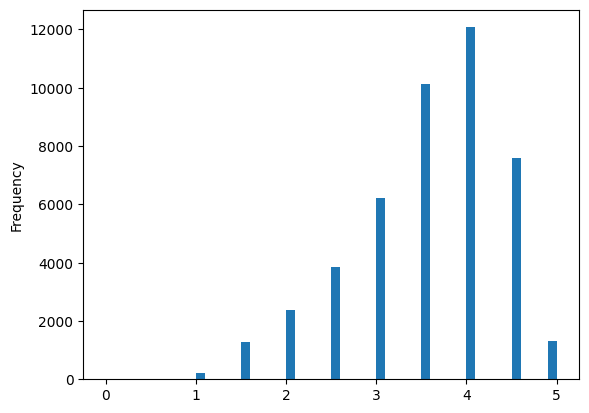

In [ ]:
df_restaurants_with_hours['stars'].plot(kind ='hist', bins=50, range =(0,5))

#### Categories distribution

In [ ]:
def top_categories_counts(col, n):
    counts = (
        col
        .fillna("")
        .str.split(",")
        .explode()
        .str.strip()
    )
    category_counts = (
        counts[counts.ne("") & counts.ne("Restaurants")]
        .value_counts()
    )
    return category_counts.head(n)


In [ ]:
top_25_cat = top_categories_counts(df_restaurants_with_hours["categories"], 25)
top_25_cat

categories
Food                         13895
Nightlife                     8058
Bars                          7734
Sandwiches                    7666
American (Traditional)        7437
Pizza                         6080
Fast Food                     5980
Breakfast & Brunch            5883
American (New)                5524
Burgers                       5231
Italian                       4160
Mexican                       3927
Coffee & Tea                  3820
Seafood                       3237
Salad                         2962
Event Planning & Services     2817
Chicken Wings                 2777
Cafes                         2534
Chinese                       2523
Delis                         2118
Caterers                      1909
Specialty Food                1808
Desserts                      1738
Sports Bars                   1685
Bakeries                      1676
Name: count, dtype: int64

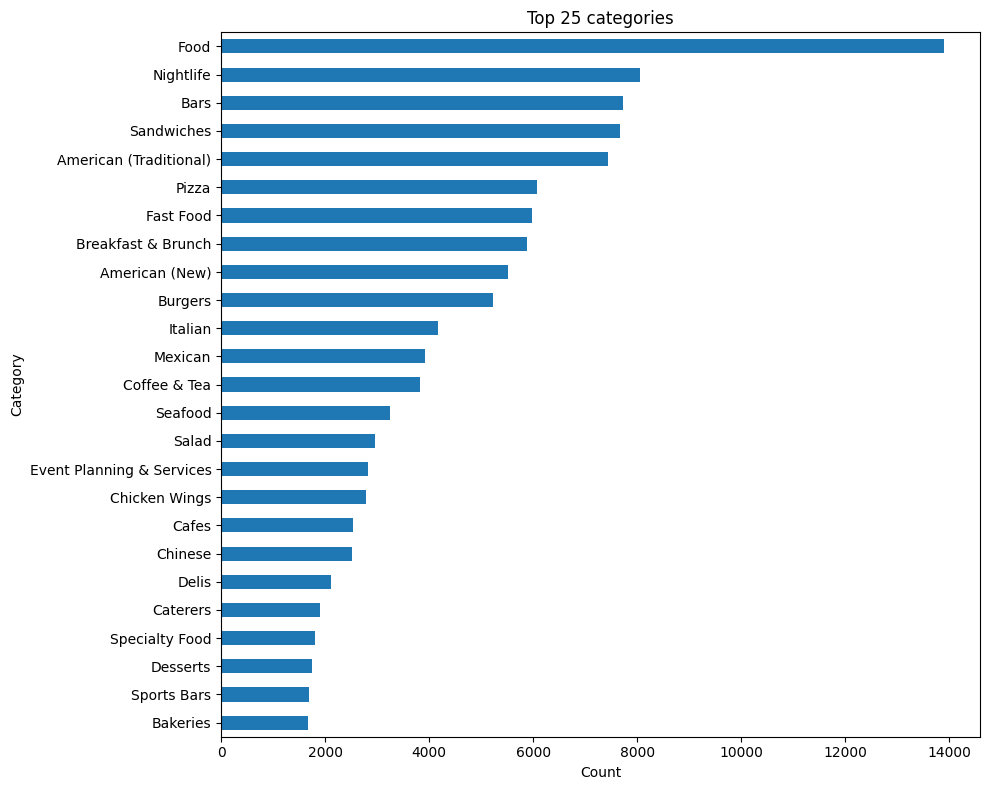

In [ ]:
top_n=25
ax = top_25_cat.sort_values().plot(kind="barh", figsize=(10, 8))
ax.set_title(f"Top {top_n} categories")
ax.set_xlabel("Count")
ax.set_ylabel("Category")
plt.tight_layout()
plt.show()

In [ ]:
df_restaurants_with_hours.to_json("../data/raw/yelp_academic_dataset_business_restaurants_with_hours.json", orient='records', lines=True)

#### Sample 1000 items

In [15]:
df_restaurants_with_hours_sample_1000=df_restaurants_with_hours.sample(n=1000, random_state =42)

<Axes: ylabel='Frequency'>

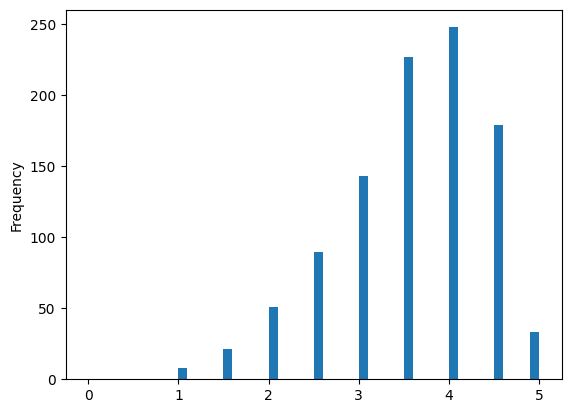

In [11]:
df_restaurants_with_hours_sample_1000['stars'].plot(kind ='hist', bins=50, range=(0,5))

In [ ]:
top_25_cat_sample_1000 = top_categories_counts(df_restaurants_with_hours_sample_1000["categories"], 25)
top_25_cat_sample_1000

categories
Food                         298
American (Traditional)       180
Sandwiches                   172
Nightlife                    145
Fast Food                    145
Bars                         140
Pizza                        140
Breakfast & Brunch           130
American (New)               118
Burgers                      106
Italian                       89
Coffee & Tea                  86
Mexican                       85
Event Planning & Services     75
Seafood                       74
Salad                         73
Chicken Wings                 68
Caterers                      60
Chinese                       54
Cafes                         52
Delis                         45
Bakeries                      39
Specialty Food                38
Japanese                      37
Desserts                      35
Name: count, dtype: int64

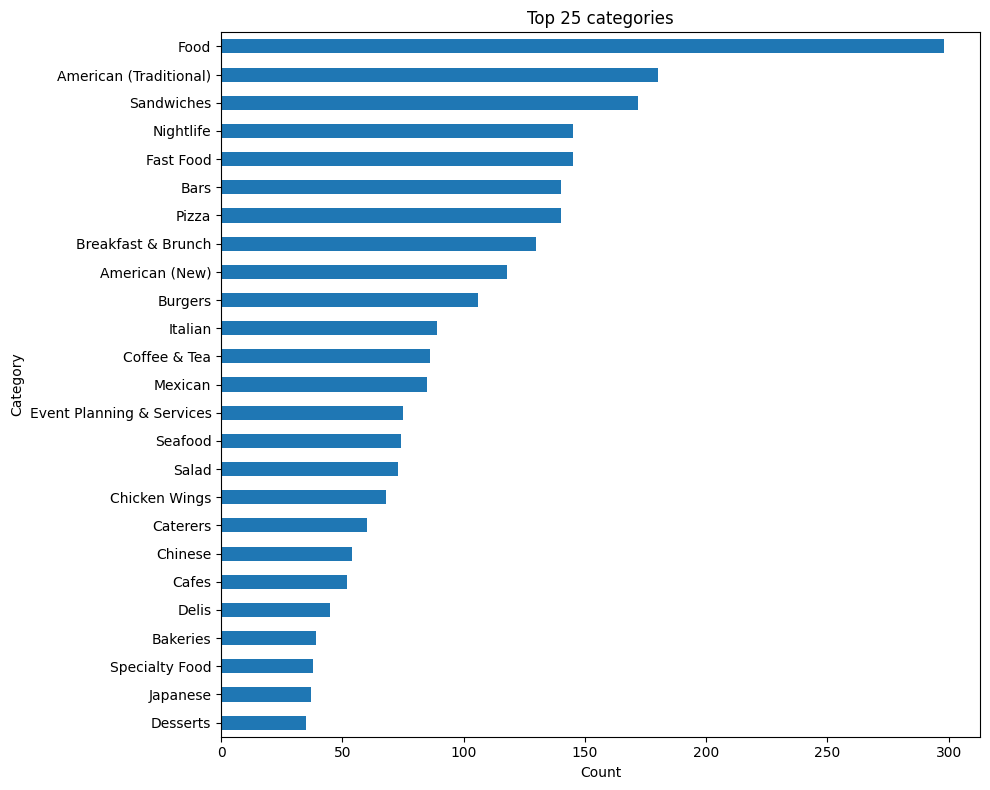

In [ ]:
top_n=25
ax = top_25_cat_sample_1000.sort_values().plot(kind="barh", figsize=(10, 8))
ax.set_title(f"Top {top_n} categories")
ax.set_xlabel("Count")
ax.set_ylabel("Category")
plt.tight_layout()
plt.show()

In [ ]:
df_restaurants_with_hours_sample_1000.to_json("../data/raw/yelp_academic_dataset_business_restaurants_with_hours_sample_1000.json", orient='records', lines=True)

In [16]:
df_restaurants_with_hours_sample_1000.describe()

,latitude,longitude,stars,review_count,is_open
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,37.034974,-87.296577,3.552500,104.894000,0.725000
std,6.113710,13.683843,0.829266,306.895783,0.446738
min,27.711310,-119.865672,1.000000,5.000000,0.000000
25%,32.190340,-90.177643,3.000000,17.000000,0.000000
50%,39.522223,-82.775454,3.500000,40.000000,1.000000
75%,39.964269,-75.299239,4.000000,104.250000,1.000000
max,53.615330,-74.712342,5.000000,6093.000000,1.000000


In [17]:
df_restaurants_with_hours_sample_1000.review_count.quantile(0.995)

np.float64(1358.6549999999993)

#### Exploring Reviews dataset

In [ ]:
# Exploring the review dataset
with  open("../data/raw/yelp_academic_dataset_review.json", "r") as f:
    first_line=json.loads(f.readline())


In [ ]:
first_line

{'review_id': 'KU_O5udG6zpxOg-VcAEodg',
 'user_id': 'mh_-eMZ6K5RLWhZyISBhwA',
 'business_id': 'XQfwVwDr-v0ZS3_CbbE5Xw',
 'stars': 3.0,
 'useful': 0,
 'funny': 0,
 'cool': 0,
 'text': "If you decide to eat here, just be aware it is going to take about 2 hours from beginning to end. We have tried it multiple times, because I want to like it! I have been to it's other locations in NJ and never had a bad experience. \n\nThe food is good, but it takes a very long time to come out. The waitstaff is very young, but usually pleasant. We have just had too many experiences where we spent way too long waiting. We usually opt for another diner or restaurant on the weekends, in order to be done quicker.",
 'date': '2018-07-07 22:09:11'}

In [ ]:
with open ("../data/raw/yelp_academic_dataset_review.json",'r') as f:
    with open("../data/raw/yelp_academic_dataset_restaurants_reviews.json", 'a', encoding='utf-8') as f_out:
            business_id_list= set(df_restaurants_with_hours['business_id'])
            i=0
            for line in f:
                data=json.loads(line.strip())
                if data['business_id'] in business_id_list:
                    json.dump(data,f_out)
                    f_out.write('\n')
                    f_out.flush()
                i+=1
                if i%10000==0:
                    print(f"Processed {i} lines")

Processed 10000 lines
Processed 20000 lines
Processed 30000 lines
Processed 40000 lines
Processed 50000 lines
Processed 60000 lines
Processed 70000 lines
Processed 80000 lines
Processed 90000 lines
Processed 100000 lines
Processed 110000 lines
Processed 120000 lines
Processed 130000 lines
Processed 140000 lines
Processed 150000 lines
Processed 160000 lines
Processed 170000 lines
Processed 180000 lines
Processed 190000 lines
Processed 200000 lines
Processed 210000 lines
Processed 220000 lines
Processed 230000 lines
Processed 240000 lines
Processed 250000 lines
Processed 260000 lines
Processed 270000 lines
Processed 280000 lines
Processed 290000 lines
Processed 300000 lines
Processed 310000 lines
Processed 320000 lines
Processed 330000 lines
Processed 340000 lines
Processed 350000 lines
Processed 360000 lines
Processed 370000 lines
Processed 380000 lines
Processed 390000 lines
Processed 400000 lines
Processed 410000 lines
Processed 420000 lines
Processed 430000 lines
Processed 440000 lin

In [ ]:
with open ("../data/raw/yelp_academic_dataset_restaurants_reviews.json",'r') as f:
    with open("../data/raw/yelp_academic_dataset_restaurants_reviews_sample.json", 'a', encoding='utf-8') as f_out:
            business_id_list= set(df_restaurants_with_hours_sample_1000['business_id'])
            i=0
            for line in f:
                data=json.loads(line.strip())
                if data['business_id'] in business_id_list:
                    json.dump(data,f_out)
                    f_out.write('\n')
                    f_out.flush()
                i+=1
                if i%10000==0:
                    print(f"Processed {i} lines")

Processed 10000 lines
Processed 20000 lines
Processed 30000 lines
Processed 40000 lines
Processed 50000 lines
Processed 60000 lines
Processed 70000 lines
Processed 80000 lines
Processed 90000 lines
Processed 100000 lines
Processed 110000 lines
Processed 120000 lines
Processed 130000 lines
Processed 140000 lines
Processed 150000 lines
Processed 160000 lines
Processed 170000 lines
Processed 180000 lines
Processed 190000 lines
Processed 200000 lines
Processed 210000 lines
Processed 220000 lines
Processed 230000 lines
Processed 240000 lines
Processed 250000 lines
Processed 260000 lines
Processed 270000 lines
Processed 280000 lines
Processed 290000 lines
Processed 300000 lines
Processed 310000 lines
Processed 320000 lines
Processed 330000 lines
Processed 340000 lines
Processed 350000 lines
Processed 360000 lines
Processed 370000 lines
Processed 380000 lines
Processed 390000 lines
Processed 400000 lines
Processed 410000 lines
Processed 420000 lines
Processed 430000 lines
Processed 440000 lin

### Explore the image dataset

In [11]:


# Load photos metadata
photos_meta_path = Path("../data/raw/photos.json")
df_photos = pd.read_json(photos_meta_path, lines=True)

# Attach local image paths from `../data/raw/photos/`
photos_dir = Path("../data/raw/photos")
df_photos["photo_filename"] = df_photos["photo_id"].astype(str) + ".jpg"
df_photos["photo_path"] = df_photos["photo_filename"].map(lambda fn: str(photos_dir / fn))
df_photos["photo_exists"] = df_photos["photo_filename"].map(lambda fn: (photos_dir / fn).is_file())

# Load actual photo bytes (ONLY for files that exist locally)
# This keeps memory reasonable even though df_photos has 200k+ rows.
existing_paths = df_photos.loc[df_photos["photo_exists"], "photo_path"].tolist()
path_to_bytes = {p: Path(p).read_bytes() for p in existing_paths}

# Store embeddable content in the table
# - `photo_bytes`: raw JPEG bytes
# - `photo_b64`: base64 string (handy for HTML <img src="data:...">)
df_photos["photo_bytes"] = df_photos["photo_path"].map(path_to_bytes)
df_photos["photo_b64"] = df_photos["photo_bytes"].map(
    lambda b: None if b is None else base64.b64encode(b).decode("ascii")
)
df_photos["photo_data_uri"] = df_photos["photo_b64"].map(
    lambda s: None if s is None else f"data:image/jpeg;base64,{s}"
)

missing = int((~df_photos["photo_exists"]).sum())
print(f"Photos in metadata: {len(df_photos):,}")
print(f"Photos present on disk: {len(existing_paths):,}")
print(f"Photos missing on disk: {missing:,}")

df_photos[df_photos["photo_exists"]].head()

Photos in metadata: 200,100
Photos present on disk: 200,100
Photos missing on disk: 0


,photo_id,business_id,caption,label,photo_filename,photo_path,photo_exists,photo_bytes,photo_b64,photo_data_uri
0,zsvj7vloL4L5jhYyPIuVwg,Nk-SJhPlDBkAZvfsADtccA,Nice rock artwork everywhere and craploads of ...,inside,zsvj7vloL4L5jhYyPIuVwg.jpg,../data/raw/photos/zsvj7vloL4L5jhYyPIuVwg.jpg,True,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,/9j/4AAQSkZJRgABAQAAAQABAAD/2wCEAAYGBgYHBgcICA...,"data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQA..."
1,HCUdRJHHm_e0OCTlZetGLg,yVZtL5MmrpiivyCIrVkGgA,,outside,HCUdRJHHm_e0OCTlZetGLg.jpg,../data/raw/photos/HCUdRJHHm_e0OCTlZetGLg.jpg,True,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUDBAQEAwUEBA...,"data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQA..."
2,vkr8T0scuJmGVvN2HJelEA,_ab50qdWOk0DdB6XOrBitw,oyster shooter,drink,vkr8T0scuJmGVvN2HJelEA.jpg,../data/raw/photos/vkr8T0scuJmGVvN2HJelEA.jpg,True,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,"data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQA..."
3,pve7D6NUrafHW3EAORubyw,SZU9c8V2GuREDN5KgyHFJw,Shrimp scampi,food,pve7D6NUrafHW3EAORubyw.jpg,../data/raw/photos/pve7D6NUrafHW3EAORubyw.jpg,True,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAYEBQYFBAYGBQ...,"data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQA..."
4,H52Er-uBg6rNrHcReWTD2w,Gzur0f0XMkrVxIwYJvOt2g,,food,H52Er-uBg6rNrHcReWTD2w.jpg,../data/raw/photos/H52Er-uBg6rNrHcReWTD2w.jpg,True,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUDBAQEAwUEBA...,"data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQA..."



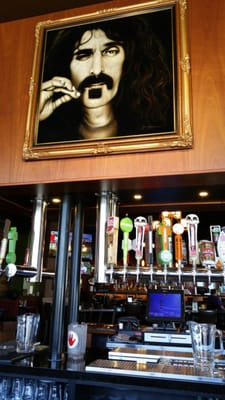

In [12]:
from IPython.display import HTML, display

uri = df_photos.loc[df_photos["photo_id"] == "zsvj7vloL4L5jhYyPIuVwg", "photo_data_uri"].iloc[0]

display(HTML(f"<img src='{uri}' style='max-width:400px; height:auto;' />"))

In [13]:
caption= df_photos.loc[df_photos["photo_id"] == "zsvj7vloL4L5jhYyPIuVwg", "caption"].iloc[0]
caption

'Nice rock artwork everywhere and craploads of taps.'

In [14]:
business_id_list= set(df_restaurants_with_hours_sample_1000['business_id'])

In [15]:
df_photos_restaurants_sample = df_photos[df_photos["business_id"].isin(business_id_list)]

In [16]:
len(df_photos_restaurants_sample)

3731

In [17]:
df_photos_restaurants_sample.head()

,photo_id,business_id,caption,label,photo_filename,photo_path,photo_exists,photo_bytes,photo_b64,photo_data_uri
22,J1rqVl8pAoMJtPfGA2HV9w,jkGQQ4_LgJx3hwPtCFkzbQ,,outside,J1rqVl8pAoMJtPfGA2HV9w.jpg,../data/raw/photos/J1rqVl8pAoMJtPfGA2HV9w.jpg,True,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,/9j/4AAQSkZJRgABAQAAAQABAAD/2wCEAAUFBQUFBQUGBg...,"data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQA..."
38,UEwMittQNRLc9956JjphpQ,5zqvErekexa_89W6-6uZ4g,Comfy booths and chairs,inside,UEwMittQNRLc9956JjphpQ.jpg,../data/raw/photos/UEwMittQNRLc9956JjphpQ.jpg,True,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUDBAQEAwUEBA...,"data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQA..."
49,fWq21Bfj89geWTcaCyFMHQ,B14QVaV7ohfMmHldumd5aw,Hamburger pizza.,food,fWq21Bfj89geWTcaCyFMHQ.jpg,../data/raw/photos/fWq21Bfj89geWTcaCyFMHQ.jpg,True,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUDBAQEAwUEBA...,"data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQA..."
156,PjHN7jZsFz1XzZagvExKWA,q1LlkxzJ1VEzKedgPrcDlw,,food,PjHN7jZsFz1XzZagvExKWA.jpg,../data/raw/photos/PjHN7jZsFz1XzZagvExKWA.jpg,True,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAYEBQYFBAYGBQ...,"data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQA..."
276,919jq1Q_goCSf7zZoXeQ1A,-IQsXtexaUmIfSBkhBZrKQ,,food,919jq1Q_goCSf7zZoXeQ1A.jpg,../data/raw/photos/919jq1Q_goCSf7zZoXeQ1A.jpg,True,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,/9j/4AAQSkZJRgABAQAAAQABAAD/2wCEAAUFBQUFBQUGBg...,"data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQA..."



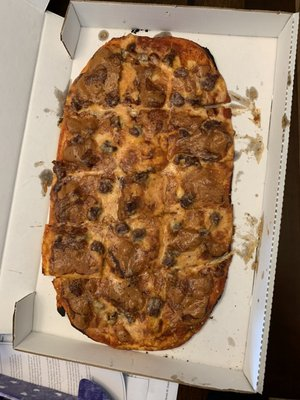

In [18]:
from IPython.display import HTML, display

uri = df_photos_restaurants_sample.loc[df_photos_restaurants_sample["photo_id"] == "fWq21Bfj89geWTcaCyFMHQ", "photo_data_uri"].iloc[0]

display(HTML(f"<img src='{uri}' style='max-width:400px; height:auto;' />"))

In [19]:
caption= df_photos.loc[df_photos["photo_id"] == "fWq21Bfj89geWTcaCyFMHQ", "caption"].iloc[0]
caption


'Hamburger pizza.'

In [20]:
cols_to_save = [
    "photo_id",
    "business_id",
    "caption",
    "label",
    # "photo_path",
    # "photo_b64",      # or "photo_data_uri"
    # any other *text/number* columns you want
]


In [21]:
df_photos_restaurants_sample[cols_to_save].to_json(
    "../data/raw/photos_restaurants_sample.json",
    orient="records",
    lines=True,
    force_ascii=False,  # optional: allow full Unicode
)

### Exploring Tip


In [22]:
with  open("../data/raw/yelp_academic_dataset_tip.json", "r") as f:
    first_line=json.loads(f.readline())

In [23]:
first_line

{'user_id': 'AGNUgVwnZUey3gcPCJ76iw',
 'business_id': '3uLgwr0qeCNMjKenHJwPGQ',
 'text': 'Avengers time with the ladies.',
 'date': '2012-05-18 02:17:21',
 'compliment_count': 0}

In [24]:
business_id_list= set(df_restaurants_with_hours_sample_1000['business_id'])

In [25]:
df_tip=pd.read_json("../data/raw/yelp_academic_dataset_tip.json", lines=True)

In [26]:
len(df_tip)

908915

In [27]:
df_tip_sample = df_tip[df_tip["business_id"].isin(business_id_list)]

In [28]:
len(df_tip_sample)

14110

In [29]:
df_tip_sample['text'].isna().sum()

np.int64(0)

In [30]:
df_tip_sample.to_json(
    "../data/raw/yelp_academic_dataset_restaurants_tip_sample.json",
    orient="records",
    lines=True)